In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import pyarrow.dataset as ds
warnings.filterwarnings('ignore')

In [ ]:
# ── Config ───────────────────────────────────────────────────────────────────
ROOT_DIR        = r"D:\ProyekDosen\RisetBearing"
INPUT_PARQUET   = os.path.join(ROOT_DIR, "bearing_1_full.parquet")
OUTPUT_PARQUET  = os.path.join(ROOT_DIR, "Dataset", "bearing_1", "processed_bearing1.parquet")

SAMPLING_RATE    = 2560
SEGMENT_SECONDS  = 60
SAMPLES_PER_SEG  = SAMPLING_RATE * SEGMENT_SECONDS
N_SEGMENTS       = 108 * 60
FR               = 3000 / 60

D_PITCH, D_BALL, Z_BALLS = 33.5, 7.94, 8
ALPHA_RAD = 0.0
DEFECT_BW = 5.0

DEGRADATION_TYPE    = 'linear'
TARGET_TCP_AXIS     = 'y'
CUSUM_K             = 1.0
CUSUM_H             = 8.0
EMA_SPAN            = 20
CUSUM_BASELINE_FRAC = 0.50

AXES = ['x', 'y', 'z']

plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 10, 'axes.grid': True,
    'grid.alpha': 0.3, 'lines.linewidth': 1.4, 'legend.fontsize': 9,
})

In [3]:
# ── Defect Frequencies ───────────────────────────────────────────────────────
def compute_defect_frequencies(fr, D, d, Z, alpha):
    """Standard bearing kinematic frequency equations."""
    ratio = (d / D) * np.cos(alpha)
    return (Z/2)*fr*(1-ratio), (Z/2)*fr*(1+ratio), (D/(2*d))*fr*(1-ratio**2)

BPFO, BPFI, BSF = compute_defect_frequencies(FR, D_PITCH, D_BALL, Z_BALLS, ALPHA_RAD)
defect_freqs = {'BPFO': BPFO, 'BPFI': BPFI, 'BSF': BSF}
print(f"BPFO={BPFO:.2f} Hz  BPFI={BPFI:.2f} Hz  BSF={BSF:.2f} Hz")

# ── Feature Extraction ───────────────────────────────────────────────────────
def extract_time_domain(data):
    """11 time-domain features; data shape (N, S, A) → dict of (N, A) arrays."""
    mean_abs    = np.mean(np.abs(data), axis=1)
    mean_sq_abs = np.mean(np.sqrt(np.abs(data)), axis=1)
    rms         = np.sqrt(np.mean(data**2, axis=1))
    peak        = np.max(np.abs(data), axis=1)
    N, S, A     = data.shape
    skew = np.zeros((N, A), np.float32)
    kurt = np.zeros((N, A), np.float32)
    for a in range(A):
        skew[:, a] = stats.skew(data[:, :, a], axis=1)
        kurt[:, a] = stats.kurtosis(data[:, :, a], axis=1)
    return {
        'td_mean'            : np.mean(data, axis=1),
        'td_std'             : np.std(data, axis=1, ddof=1),
        'td_rms'             : rms,
        'td_peak_value'      : peak,
        'td_p2p'             : np.max(data, axis=1) - np.min(data, axis=1),
        'td_skewness'        : skew,
        'td_kurtosis'        : kurt,
        'td_peak_factor'     : peak / (rms + 1e-12),
        'td_clearance_factor': peak / (mean_sq_abs**2 + 1e-12),
        'td_shape_factor'    : rms / (mean_abs + 1e-12),
        'td_impulse_factor'  : peak / (mean_abs + 1e-12),
    }

def extract_frequency_domain(data, fs, d_freqs, bw):
    """FFT spectral features + defect band energies; data shape (N, S, A)."""
    N, S, A  = data.shape
    freqs    = np.fft.rfftfreq(S, d=1.0/fs)
    fft_amp  = np.abs(np.fft.rfft(data, axis=1)) / S
    freq_mat = freqs[np.newaxis, :, np.newaxis]
    amp_sum  = np.sum(fft_amp, axis=1, keepdims=True) + 1e-12
    mean_f   = np.sum(freq_mat * fft_amp, axis=1) / amp_sum.squeeze(1)

    def band_e(center):
        mask = (freqs >= center - bw) & (freqs <= center + bw)
        return np.sum(fft_amp[:, mask, :]**2, axis=1)

    return {
        'fd_mean_freq'      : mean_f,
        'fd_centroid_freq'  : mean_f.copy(),
        'fd_fft_p2p'        : np.max(fft_amp, axis=1) - np.min(fft_amp, axis=1),
        'fd_spectral_energy': np.sum(fft_amp**2, axis=1),
        'fd_bpfo_energy'    : band_e(d_freqs['BPFO']),
        'fd_bpfi_energy'    : band_e(d_freqs['BPFI']),
        'fd_bsf_energy'     : band_e(d_freqs['BSF']),
    }, fft_amp, freqs

BPFO=152.60 Hz  BPFI=247.40 Hz  BSF=99.55 Hz


In [4]:
# ── Load Raw & Stream-Extract Features ──────────────────────────────────────
dataset      = ds.dataset(INPUT_PARQUET, format="parquet")
schema_names = dataset.schema.names
col_x = [c for c in schema_names if c.strip().lower() == 'x'][0]
col_y = [c for c in schema_names if c.strip().lower() == 'y'][0]
col_z = [c for c in schema_names if c.strip().lower() == 'z'][0]
target_cols  = [col_x, col_y, col_z]

TD_NAMES = ['td_mean','td_std','td_rms','td_peak_value','td_p2p','td_skewness',
            'td_kurtosis','td_peak_factor','td_clearance_factor','td_shape_factor','td_impulse_factor']
FD_NAMES = ['fd_mean_freq','fd_centroid_freq','fd_fft_p2p','fd_spectral_energy',
            'fd_bpfo_energy','fd_bpfi_energy','fd_bsf_energy']

td_acc = {k: [] for k in TD_NAMES}
fd_acc = {k: [] for k in FD_NAMES}

seg_count  = 0
buf        = np.empty((SAMPLES_PER_SEG, 3), dtype=np.float32)
buf_idx    = 0

print("Streaming feature extraction...")
for batch in dataset.to_batches(columns=target_cols, batch_size=SAMPLES_PER_SEG):
    if seg_count >= N_SEGMENTS:
        break
    chunk = batch.to_pandas().values.astype(np.float32)
    pos   = 0
    while pos < len(chunk) and seg_count < N_SEGMENTS:
        take = min(SAMPLES_PER_SEG - buf_idx, len(chunk) - pos)
        buf[buf_idx:buf_idx+take] = chunk[pos:pos+take]
        buf_idx += take
        pos     += take
        if buf_idx == SAMPLES_PER_SEG:
            seg = buf.reshape(1, SAMPLES_PER_SEG, 3)
            td  = extract_time_domain(seg)
            fd, _, _ = extract_frequency_domain(seg, SAMPLING_RATE, defect_freqs, DEFECT_BW)
            for k in TD_NAMES: td_acc[k].append(td[k][0])
            for k in FD_NAMES: fd_acc[k].append(fd[k][0])
            seg_count += 1
            buf_idx    = 0
            if seg_count % 1500 == 0:
                print(f"  {seg_count}/{N_SEGMENTS} segments done")

print(f"Extraction complete — {seg_count} segments")

seg_time  = np.arange(seg_count) * SEGMENT_SECONDS
feat_dict = {'segment': np.arange(seg_count), 'time_s': seg_time, 'time_min': seg_time/60}

for name, lst in td_acc.items():
    arr = np.array(lst)
    for i, ax in enumerate(AXES):
        feat_dict[f"{name}_{ax}"] = arr[:, i].astype(np.float64)

for name, lst in fd_acc.items():
    arr = np.array(lst)
    for i, ax in enumerate(AXES):
        feat_dict[f"{name}_{ax}"] = arr[:, i].astype(np.float64)

df = pd.DataFrame(feat_dict)
print(f"Feature matrix: {df.shape}")

Streaming feature extraction...
  1500/6480 segments done
  3000/6480 segments done
  4500/6480 segments done
  6000/6480 segments done
Extraction complete — 6480 segments
Feature matrix: (6480, 57)


In [5]:
# ── EMA Smoothing ────────────────────────────────────────────────────────────
for ax in AXES:
    df[f"rms_ema_{ax}"] = df[f"td_rms_{ax}"].ewm(span=EMA_SPAN, adjust=False).mean()

# ── CUSUM Change-Point Detection ─────────────────────────────────────────────
def cusum_detection(series, k, h, baseline_frac):
    """One-sided upper CUSUM; returns cumulative sum array and TCP index."""
    n_base = max(1, int(len(series) * baseline_frac))
    mu, sigma = series[:n_base].mean(), series[:n_base].std(ddof=1)
    z = (series - mu) / (sigma + 1e-12)
    S = np.zeros(len(z))
    for i in range(1, len(z)):
        S[i] = max(0.0, S[i-1] + z[i] - k)
    crossings = np.where(S > h)[0]
    tcp = int(crossings[0]) if len(crossings) else len(series) - 1
    return S, tcp

cusum_col      = f"rms_ema_{TARGET_TCP_AXIS}"
S_cusum, tcp_i = cusum_detection(df[cusum_col].values, CUSUM_K, CUSUM_H, CUSUM_BASELINE_FRAC)
T_cp_segment   = tcp_i
T_cp_min       = df.loc[tcp_i, 'time_min']
print(f"TCP detected: segment {T_cp_segment}  ({T_cp_min:.1f} min / {T_cp_min/60:.2f} h)")


TCP detected: segment 2381  (2381.0 min / 39.68 h)


In [6]:
# ── BHI Labeling ─────────────────────────────────────────────────────────────
def compute_bhi(n, tcp_idx, degradation_type):
    """BHI=1 before TCP, degrades to 0 at end."""
    bhi    = np.ones(n)
    t_norm = np.linspace(0, 1, n - tcp_idx)
    if degradation_type == 'linear':
        bhi[tcp_idx:] = 1 - t_norm
    elif degradation_type == 'sigmoid':
        k = 10
        s = 1 - 1/(1 + np.exp(-k*(t_norm - 0.5)))
        bhi[tcp_idx:] = (s - s.min()) / (s.max() - s.min() + 1e-12)
        bhi[tcp_idx:] = 1 - bhi[tcp_idx:]
    return np.clip(bhi, 0, 1)

bhi = compute_bhi(seg_count, T_cp_segment, DEGRADATION_TYPE)
df['bhi']      = bhi
df['label_vcd']= (df['segment'] >= T_cp_segment).astype(int)
df['T_cp']     = T_cp_segment
df['T_f']      = seg_count - 1

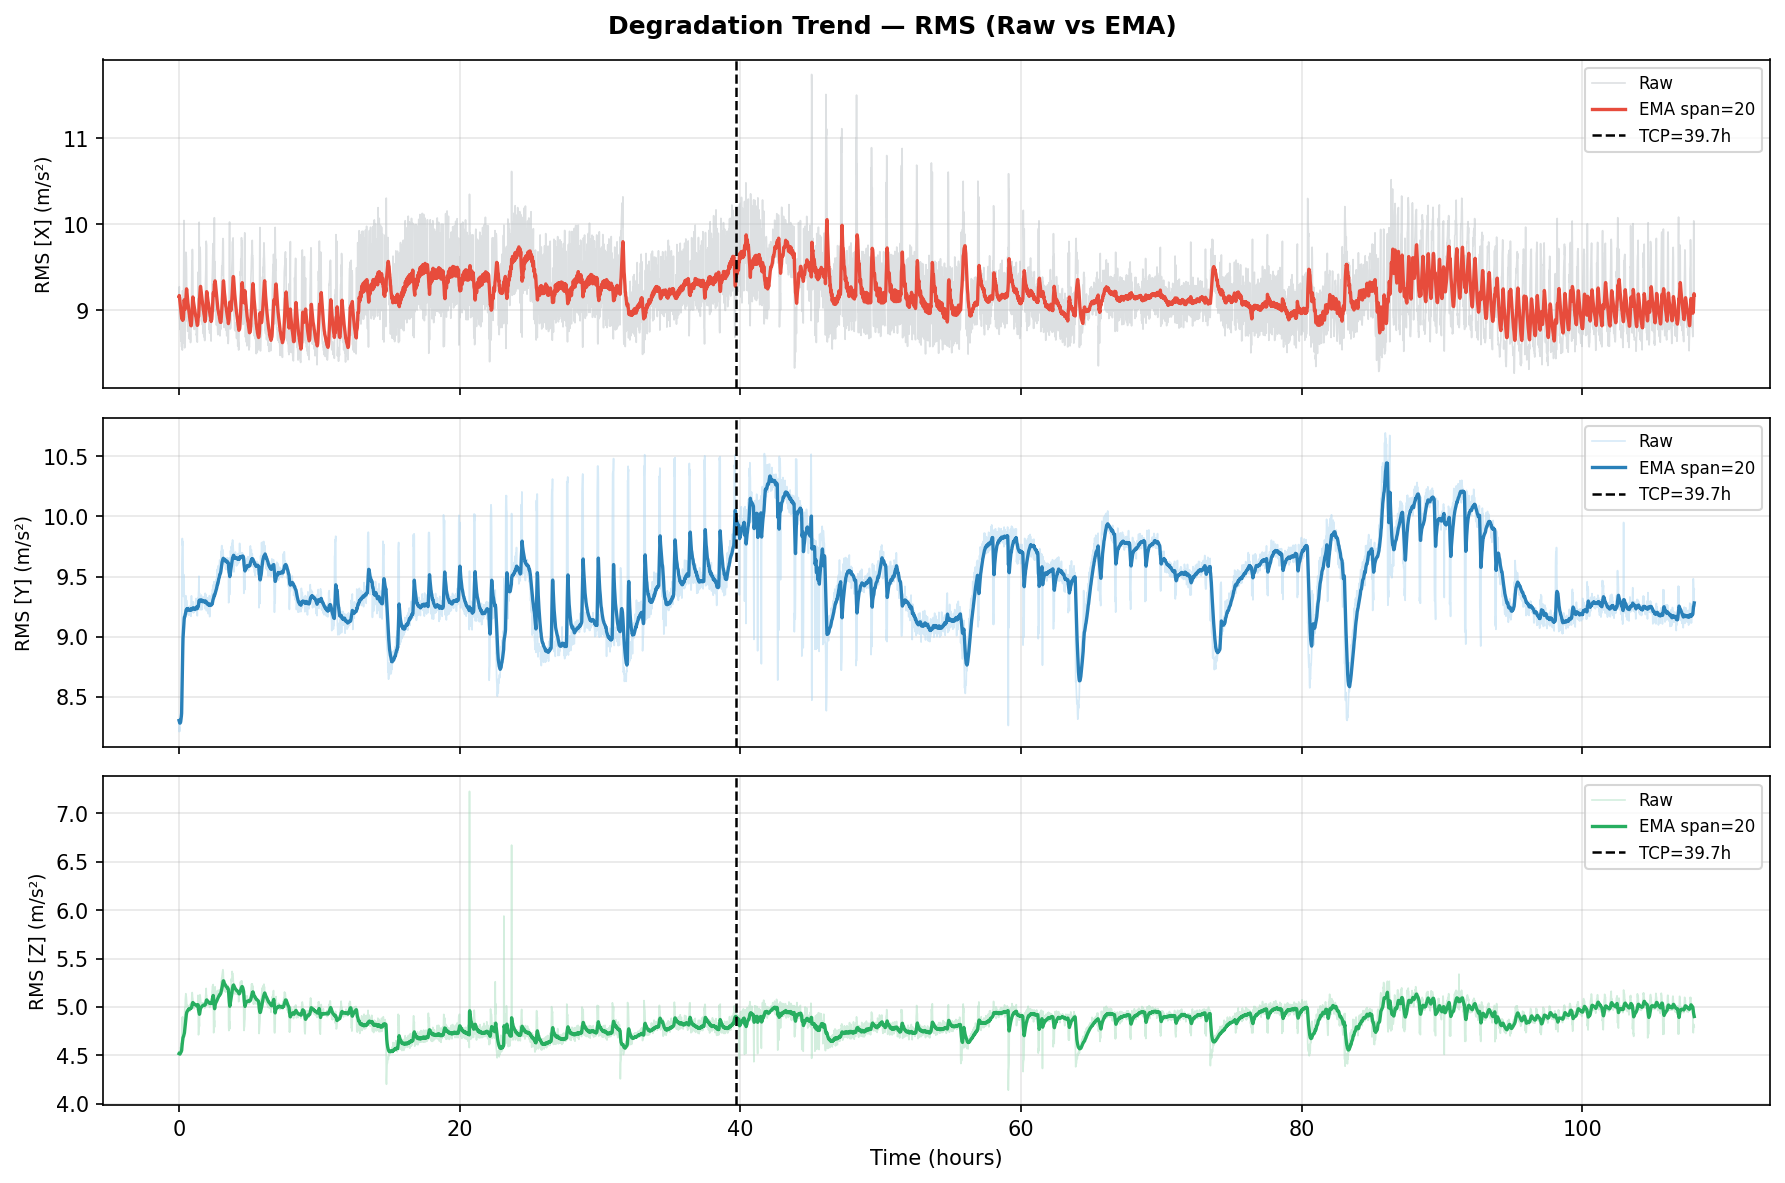

In [7]:
# ── Visualizations ───────────────────────────────────────────────────────────
t_h = df['time_min'].values / 60
tcp_h = T_cp_min / 60
colors_r = ['#BDC3C7', '#AED6F1', '#A9DFBF']
colors_s = ['#E74C3C', '#2980B9', '#27AE60']

# Plot 1: RMS raw vs smoothed
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Degradation Trend — RMS (Raw vs EMA)', fontweight='bold')
for i, ax in enumerate(AXES):
    axes[i].plot(t_h, df[f'td_rms_{ax}'],   color=colors_r[i], alpha=0.5, lw=0.8, label='Raw')
    axes[i].plot(t_h, df[f'rms_ema_{ax}'],  color=colors_s[i], lw=1.6,          label=f'EMA span={EMA_SPAN}')
    axes[i].axvline(tcp_h, color='black', ls='--', lw=1.2, label=f'TCP={tcp_h:.1f}h')
    axes[i].set_ylabel(f'RMS [{ax.upper()}] (m/s²)', fontsize=9)
    axes[i].legend(fontsize=8)
axes[-1].set_xlabel('Time (hours)')
plt.tight_layout()
plt.savefig('plot1_rms_trend.png', dpi=200, bbox_inches='tight')
plt.show()

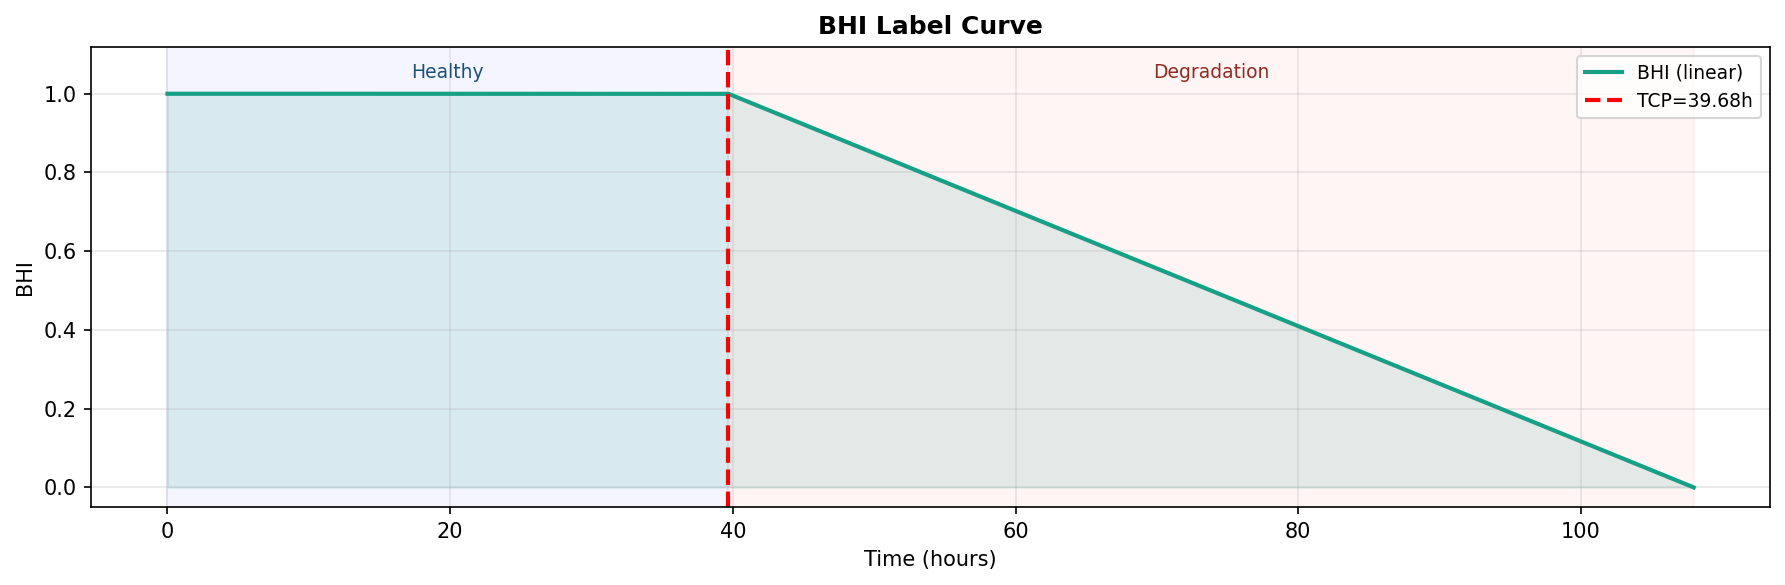

In [8]:
# Plot 2: BHI curve
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_h, bhi, color='#16A085', lw=2, label=f'BHI ({DEGRADATION_TYPE})')
ax.fill_between(t_h, 0, bhi, alpha=0.12, color='#16A085')
ax.axvline(tcp_h, color='red', lw=2, ls='--', label=f'TCP={tcp_h:.2f}h')
ax.axvspan(0, tcp_h, alpha=0.04, color='blue')
ax.axvspan(tcp_h, t_h[-1], alpha=0.04, color='red')
ax.annotate('Healthy', xy=(tcp_h/2, 1.04), ha='center', fontsize=9, color='#1A5276')
ax.annotate('Degradation', xy=((tcp_h+t_h[-1])/2, 1.04), ha='center', fontsize=9, color='#922B21')
ax.set_ylim(-0.05, 1.12)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('BHI')
ax.set_title('BHI Label Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot2_bhi_curve.png', dpi=200, bbox_inches='tight')
plt.show()

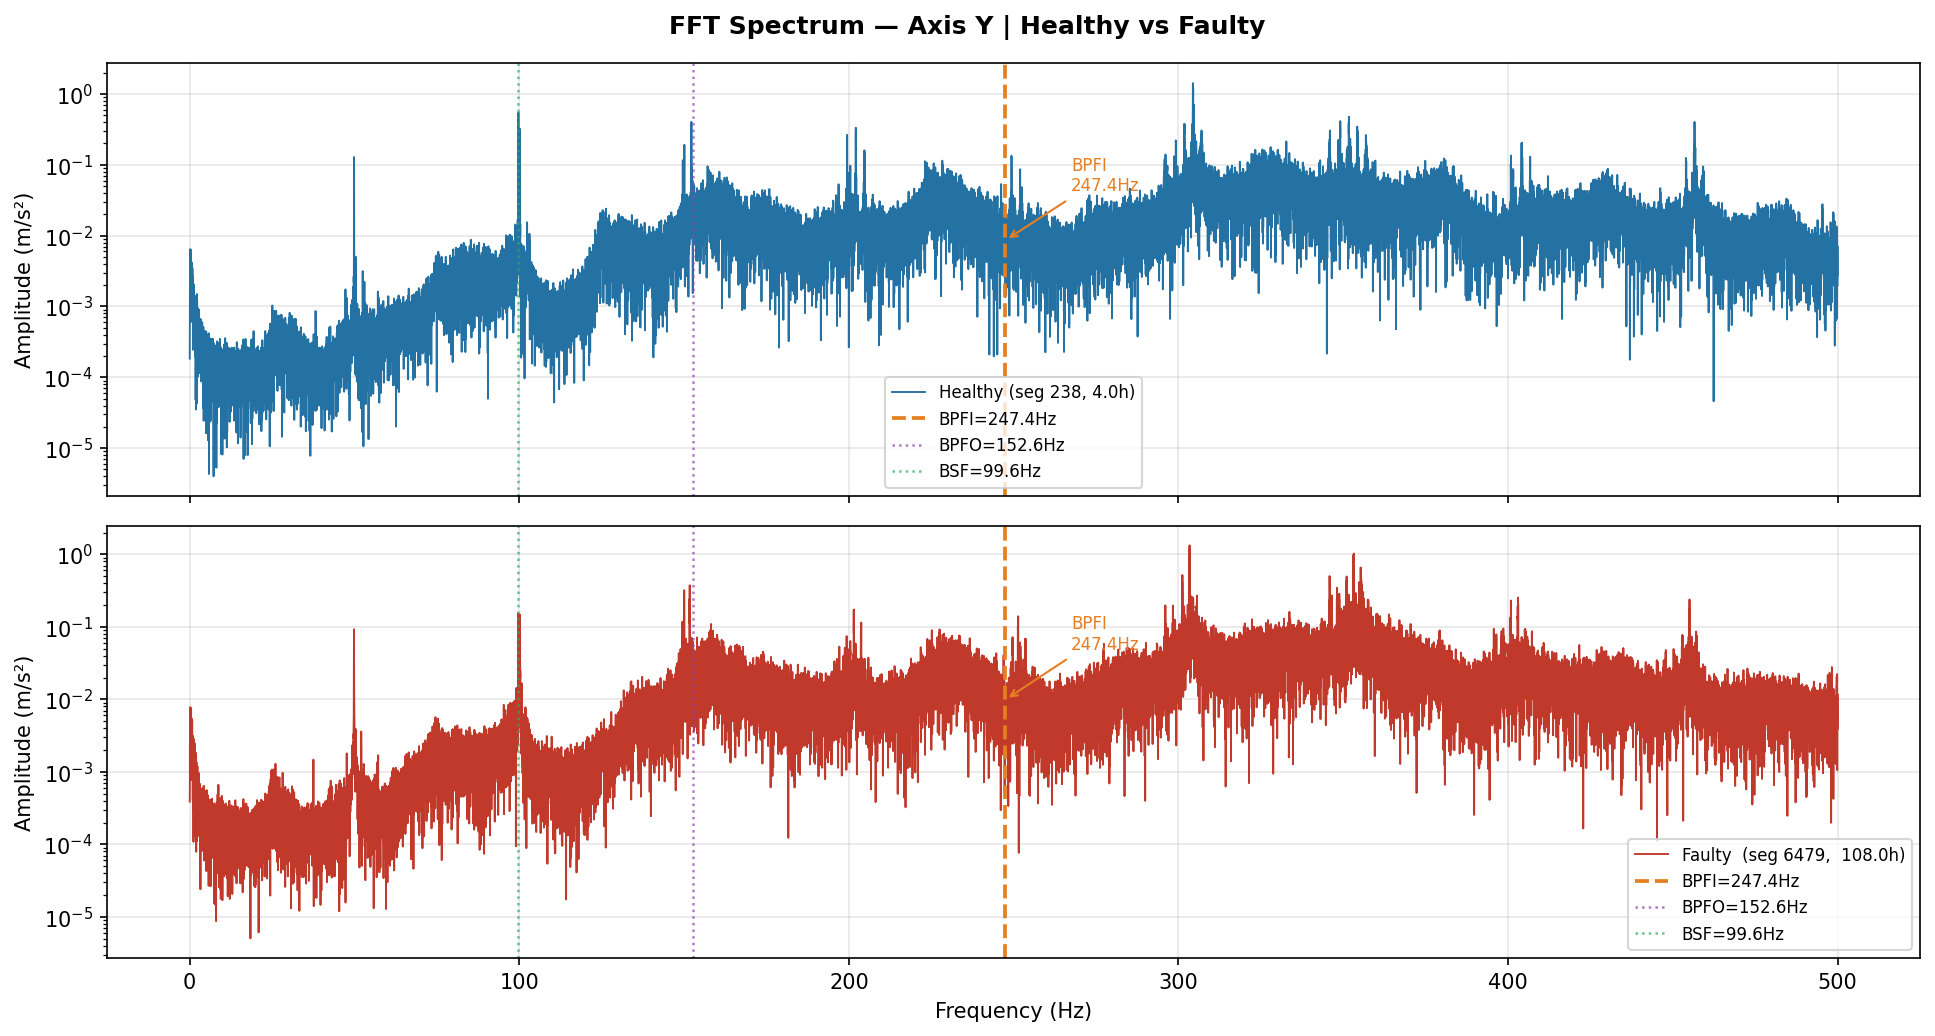

In [9]:
# Plot 3: FFT healthy vs faulty
axis_idx  = AXES.index(TARGET_TCP_AXIS)
axis_col  = target_cols[axis_idx]
healthy_i = int(T_cp_segment * 0.1)
faulty_i  = seg_count - 1

def read_segment(seg_idx, col):
    """Slice one segment from the raw dataset for a single column."""
    tbl = dataset.scanner(columns=[col]).to_table()
    return tbl.slice(seg_idx * SAMPLES_PER_SEG, SAMPLES_PER_SEG).to_pandas().values[:, 0].astype(np.float64)

freq_ax  = np.fft.rfftfreq(SAMPLES_PER_SEG, d=1.0/SAMPLING_RATE)
fft_h    = np.abs(np.fft.rfft(read_segment(healthy_i, axis_col))) * 2 / SAMPLES_PER_SEG
fft_f    = np.abs(np.fft.rfft(read_segment(faulty_i,  axis_col))) * 2 / SAMPLES_PER_SEG
mask500  = freq_ax <= 500

fig, axs = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle(f'FFT Spectrum — Axis {TARGET_TCP_AXIS.upper()} | Healthy vs Faulty', fontweight='bold')
for ax_plt, (fft_d, lbl, clr) in zip(axs, [
    (fft_h, f'Healthy (seg {healthy_i}, {healthy_i/60:.1f}h)', '#2471A3'),
    (fft_f, f'Faulty  (seg {faulty_i},  {faulty_i/60:.1f}h)',  '#C0392B'),
]):
    ax_plt.semilogy(freq_ax[mask500], fft_d[mask500]+1e-10, color=clr, lw=0.9, label=lbl)
    ax_plt.axvline(BPFI, color='#E67E22', lw=1.8, ls='--', label=f'BPFI={BPFI:.1f}Hz')
    ax_plt.axvline(BPFO, color='#8E44AD', lw=1.2, ls=':',  alpha=0.7, label=f'BPFO={BPFO:.1f}Hz')
    ax_plt.axvline(BSF,  color='#27AE60', lw=1.2, ls=':',  alpha=0.7, label=f'BSF={BSF:.1f}Hz')
    bpfi_amp = np.interp(BPFI, freq_ax, fft_d)
    ax_plt.annotate(f'BPFI\n{BPFI:.1f}Hz', xy=(BPFI, bpfi_amp),
                    xytext=(BPFI+20, bpfi_amp*5),
                    arrowprops=dict(arrowstyle='->', color='#E67E22'), fontsize=8, color='#E67E22')
    ax_plt.set_ylabel('Amplitude (m/s²)')
    ax_plt.legend(fontsize=8)
axs[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.savefig('plot3_fft_spectrum.png', dpi=200, bbox_inches='tight')
plt.show()


In [10]:
# ── Scale & Save ─────────────────────────────────────────────────────────────
meta_cols = ['segment','time_s','time_min','bhi','label_vcd','T_cp','T_f']
ema_cols  = [c for c in df.columns if c.startswith('rms_ema_')]
feat_cols = [c for c in df.columns if c not in meta_cols + ema_cols]

df_out             = df.copy()
df_out[feat_cols]  = MinMaxScaler().fit_transform(df[feat_cols])

os.makedirs(os.path.dirname(OUTPUT_PARQUET), exist_ok=True)
df_out.to_parquet(OUTPUT_PARQUET, engine='pyarrow', index=False)

print("=" * 55)
print("PREPROCESSING SUMMARY")
print("=" * 55)
print(f"Segments          : {seg_count}  |  Features: {len(feat_cols)}")
print(f"BPFO={BPFO:.2f} Hz  BPFI={BPFI:.2f} Hz  BSF={BSF:.2f} Hz")
print(f"TCP axis          : {TARGET_TCP_AXIS.upper()}  |  Segment: {T_cp_segment}  ({T_cp_min/60:.2f} h)")
print(f"BHI               : [{bhi.min():.4f}, {bhi.max():.4f}]  type={DEGRADATION_TYPE}")
print(f"Output            : {OUTPUT_PARQUET}  shape={df_out.shape}")
print("=" * 55)


PREPROCESSING SUMMARY
Segments          : 6480  |  Features: 54
BPFO=152.60 Hz  BPFI=247.40 Hz  BSF=99.55 Hz
TCP axis          : Y  |  Segment: 2381  (39.68 h)
BHI               : [0.0000, 1.0000]  type=linear
Output            : D:\ProyekDosen\RisetBearing\Dataset\bearing_1\processed_bearing1.parquet  shape=(6480, 64)
